In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

image shape: (1280, 720)


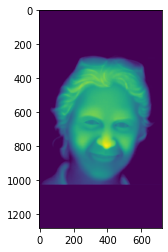

In [67]:
def load_image(fn):
    img = cv2.imread(fn)
    img = img[:,:,0]
    print("image shape:", np.shape(img))
    plt.imshow(img)
    plt.show()
    return img
img = load_image("face.png")

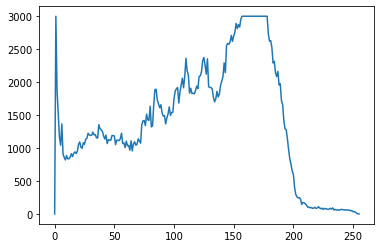

In [68]:
def get_histogram(img):
    h,_ = np.histogram(a=img, bins=256, range=(0,255))
    h[h>3000] = 3000
    h[0] = 0
    plt.plot(h)
    plt.show()
    return h
histogram = get_histogram(img)

    Algorithm: Global Thresholding Algorithm

    Start

    Chose an initial threshold value T

    Apply T to segment the image leading to two groups of pixels

     R1 are pixels with gray level > T

     R2 are pixels with gray level <= T

    Measure the average gray level values mean1 and mean2 for the pixels in R1 and R2.

    Calculate the new threshold value Tnew = (mean1 + mean2)/2

    Repeat the previous steps till the difference in T is smaller than a pre-defined threshold T0 in the successive iterations

    End

In [69]:
def get_initial_threshold(img):
    h, _ = np.histogram(a=img, bins=256, range=(0,255))
    h[0] = 0
    m = 1
    n = 255
    while m<n and h[m]==0:
        m+=1
    while n>m and h[n]==0:
        n-=1
    return (m+n)//2

In [70]:
def get_global_threshold(img):
    t0 = 255
    t1 = get_initial_threshold(img)
    while t1 < t0:
        m1 = img > t1
        m2 = img <= t1
        r1 = img[m1]
        r2 = img[m2]
        mean1 = np.sum(r1)//np.size(r1)
        mean2 = np.sum(r2)//np.size(r2)
        t0 = t1
        t1 = (mean1 + mean2)//2
    return int(t1)

t = get_global_threshold(img)
print(t)

73


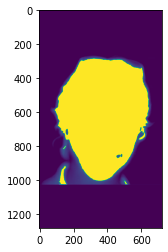

In [71]:
def segment_image(img, t):
    mask = img > t
    img1 = img.copy()
    img1[mask] = 255
    plt.imshow(img1)
    plt.show()

segment_image(img,t)

In [72]:
def split_image(img, m, n):
    return [img[x:x+M,y:y+N] for x in range(0,img.shape[0],M) for y in range(0,img.shape[1],N)]

tiles = split_image(img, 100, 100)

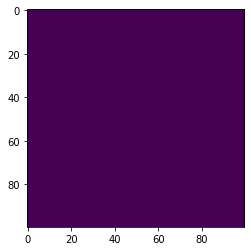

255


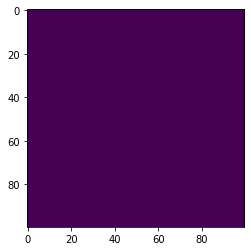

255


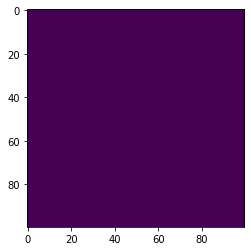

255


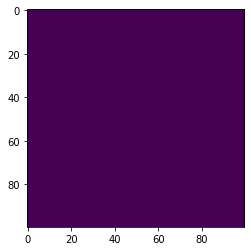

255


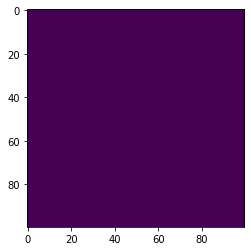

255


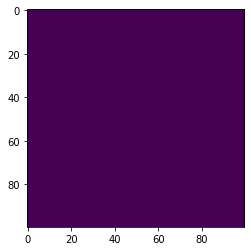

255


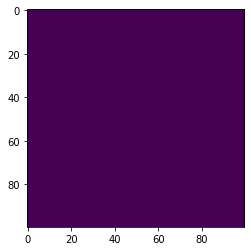

255


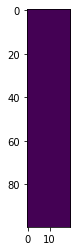

255


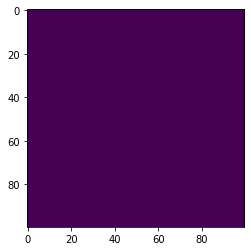

255


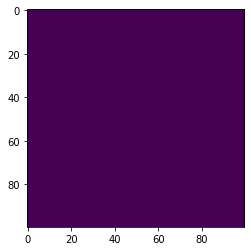

255


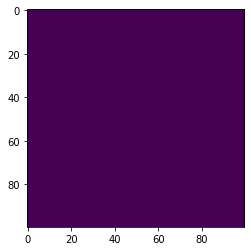

255


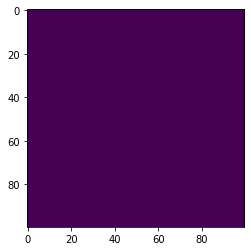

255


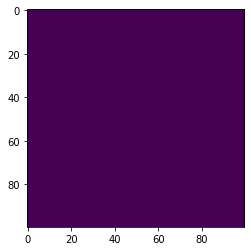

255


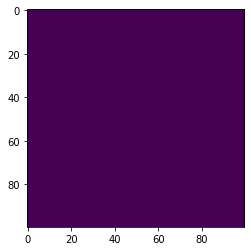

255


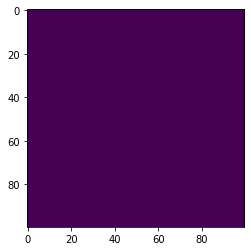

255


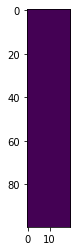

255


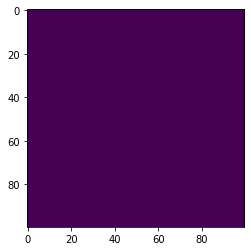

255


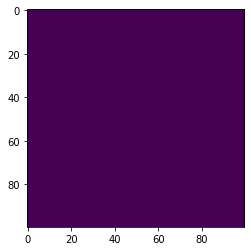

255


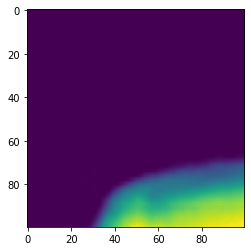

30


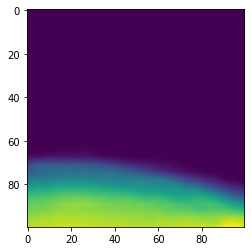

36


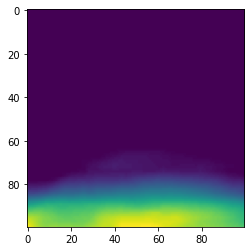

34


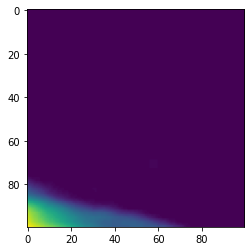

16


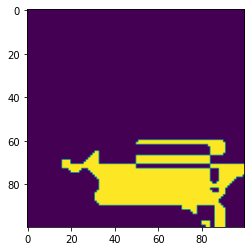

/tmp/ipykernel_3346/2573221777.py:9: RuntimeWarning: invalid value encountered in floor_divide
  mean1 = np.sum(r1)//np.size(r1)
/tmp/ipykernel_3346/2573221777.py:12: RuntimeWarning: invalid value encountered in double_scalars
  t1 = (mean1 + mean2)//2


ValueError: cannot convert float NaN to integer

In [75]:
thresholds = set()
for tile in tiles:
    plt.imshow(tile)
    plt.show()
    t = get_global_threshold(tile)
    print(t)
    thresholds.add(t)
th = list(thresholds)
list.sort(th, reverse=True)
th.pop(0)
print(th)

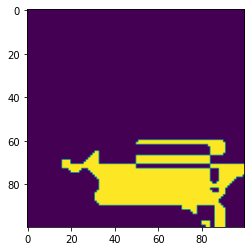

1


/tmp/ipykernel_3346/778802310.py:13: RuntimeWarning: invalid value encountered in floor_divide
  mean1 = np.sum(r1)//np.size(r1)
/tmp/ipykernel_3346/778802310.py:16: RuntimeWarning: invalid value encountered in double_scalars
  t1 = (mean1 + mean2)//2


ValueError: cannot convert float NaN to integer

In [77]:
plt.imshow(tiles[22])
plt.show()

def get_global_threshold(img):
    t0 = 255
    t1 = get_initial_threshold(img)
    while t1 < t0:
        print(t1)
        m1 = img > t1
        m2 = img <= t1
        r1 = img[m1]
        r2 = img[m2]
        s1 = np.size(r1)
        s2 = np.size(r2)
        if s1==0:
            #
        elif s2==0:
            #
        else:
            mean1 = np.sum(r1)//np.size(r1)
            mean2 = np.sum(r2)//np.size(r2)
            t0 = t1
            t1 = (mean1 + mean2)//2
    return int(t1)

t = get_global_threshold(tiles[22])
print(t)

In [78]:
h,_ = np.histogram(tiles[22], bins=256, range=(0,255))
h

array([8509, 1491,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
          0,    0,    0,    0,    0,    0,    0,   

threshold 163


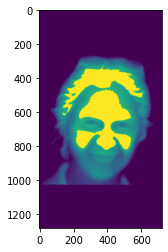

threshold 122


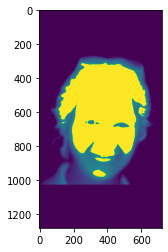

threshold 114


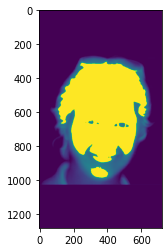

threshold 102


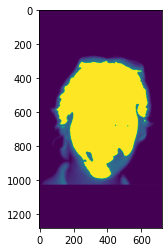

threshold 101


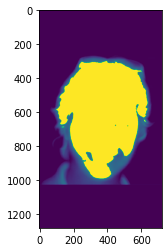

threshold 98


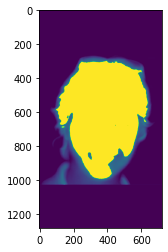

threshold 80


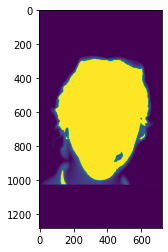

threshold 63


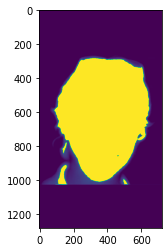

threshold 60


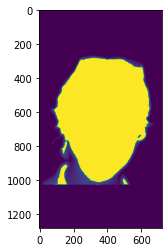

threshold 56


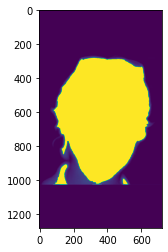

threshold 54


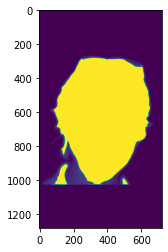

threshold 43


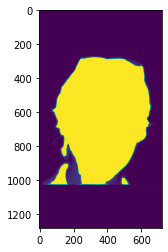

threshold 42


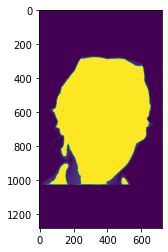

threshold 36


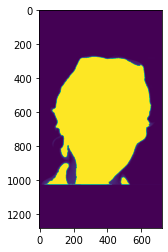

In [74]:
for t in th:
    print("threshold", t)
    segment_image(img, t)